In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from matplotlib.pyplot import figure
import seaborn as sns

In [2]:
data = pd.read_csv("song_genres_mapped_Puja.csv", parse_dates=['endTime'])
weather = pd.read_csv("vancouver_weather.csv", parse_dates=['datetime'])

In [3]:
weather = weather[['name', 'datetime', 'temp']]

In [4]:
data.loc[:, 'datetime'] = data['endTime'].dt.normalize() # removes hours values

In [5]:
merged_data = pd.merge(data, weather, on='datetime', how='inner')

**Scatterplot**

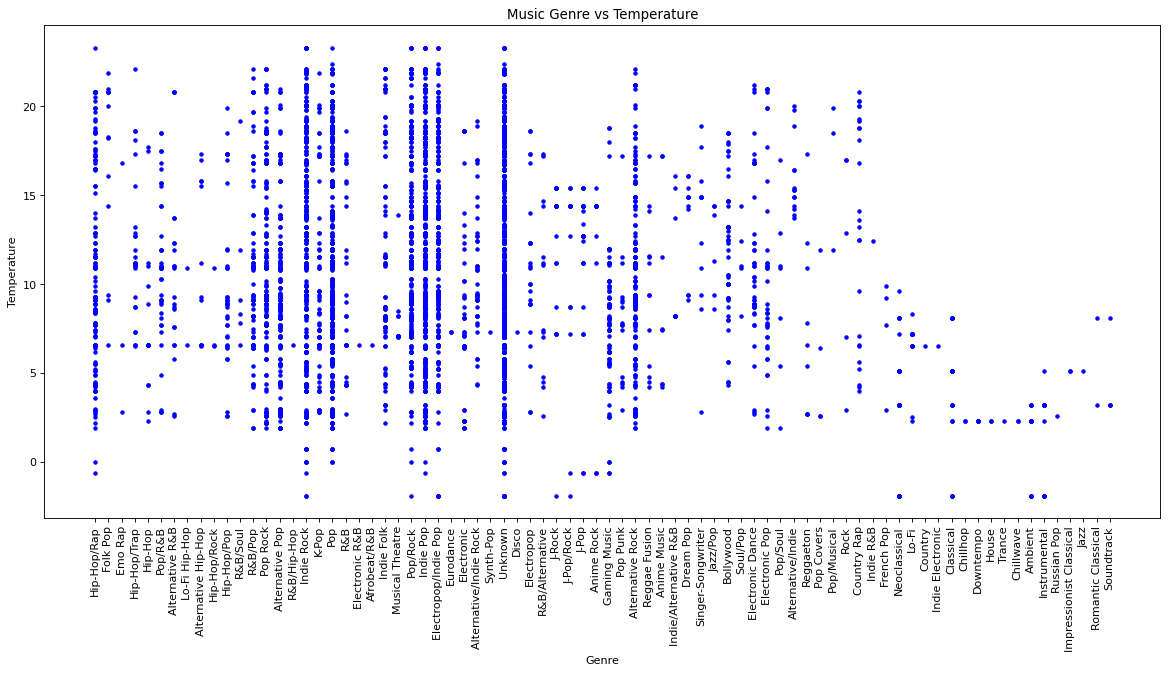

In [15]:
figure(figsize=(18, 8), dpi=80)
plt.plot(merged_data['genre'], merged_data['temp'], 'b.')
plt.title("Music Genre vs Temperature")
plt.xlabel("Genre")
plt.ylabel("Temperature")
plt.xticks(rotation=90)
plt.show()

**Histogram**

In [7]:
unique_temp = np.sort(merged_data['temp'].unique()) # unique temperatures

In [8]:
def temp_range(temp):
    range = ['below0', 'cold', 'chilly', 'warm', 'hot']
    if temp <= 0:
        return range[0]
    elif 0 < temp <= 10:
        return range[1]
    elif 10 < temp <= 20:
        return range[2]
    elif 20 < temp <= 30:
        return range[3]
    else:
        return range[4]

In [9]:
merged_data['temp_category'] = merged_data['temp'].apply(temp_range)

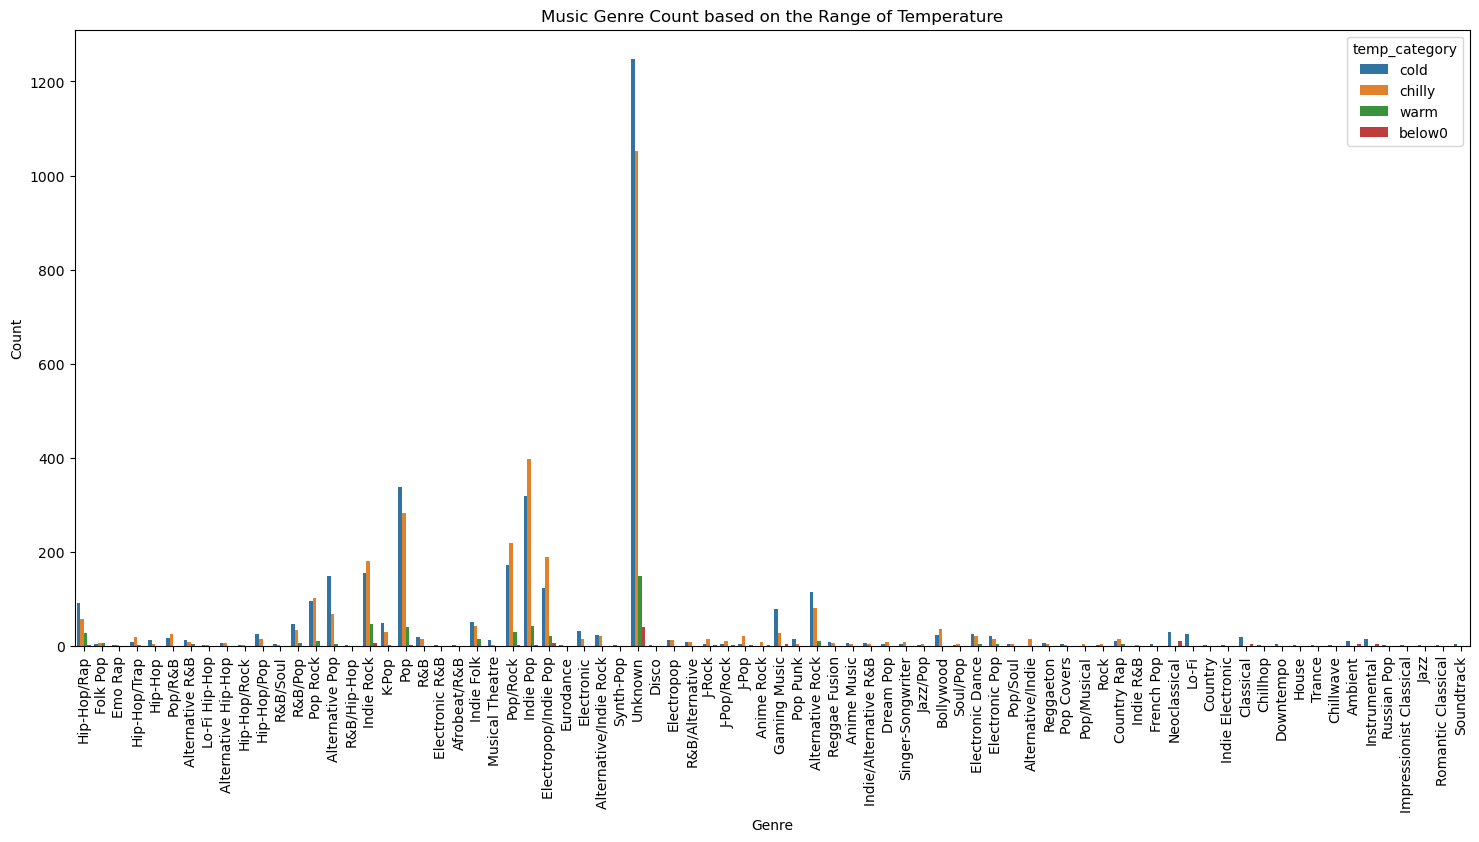

In [16]:
figure(figsize=(18, 8))
sns.countplot(data=merged_data, x='genre', hue='temp_category')
plt.title("Music Genre Count based on the Range of Temperature")
plt.xlabel("Genre")
plt.ylabel("Count")
plt.xticks(rotation=90)
plt.show()

**Anova**

In [11]:
genre_temp = merged_data.groupby('genre')['temp'].apply(list)

In [12]:
anova = stats.f_oneway(*genre_temp)
anova.pvalue # less than 0.05, there is a difference in temperature means based on genre

5.141365464192118e-67